# MSCS 634 – Lab Assignment 2

**Name:** Oishani Ganguly  
**Course Title:** MSCS-634: Advanced Big Data and Data Mining  
**Lab Assignment Title:** Lab 2: Classification Using KNN and RNN Algorithms  

---

## Dataset: Wine Dataset (sklearn)
Source: `sklearn.datasets.load_wine()`  
The Wine dataset is a classic multiclass classification benchmark containing 178 samples of wine from three cultivars grown in Italy. Each sample has 13 chemical features (e.g., alcohol content, malic acid, flavanoids) that can be used to predict which of the three wine classes a sample belongs to. It is well-suited for evaluating distance-based classifiers like KNN and Radius Neighbors.

---
## Step 1: Load and Prepare the Dataset

We begin by importing all required libraries and loading the Wine dataset directly from `sklearn`. The dataset is then converted to a Pandas DataFrame for ease of inspection. We check the shape, class distribution, and presence of any missing values before proceeding.

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

In [2]:
# Load the Wine dataset
wine = load_wine()

# Convert to DataFrame for easy inspection
df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target
df['class'] = df['target'].map({i: name for i, name in enumerate(wine.target_names)})

print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Features: {wine.feature_names}')
print(f'Classes: {list(wine.target_names)}')

Dataset shape: 178 rows × 15 columns
Features: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline']
Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [3]:
# Preview the first few rows
df.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,1065.0000,0,class_0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,1050.0000,0,class_0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,1185.0000,0,class_0
3,14.3700,1.9500,2.5000,16.8000,113.0000,3.8500,3.4900,0.2400,2.1800,7.8000,0.8600,3.4500,1480.0000,0,class_0
4,13.2400,2.5900,2.8700,21.0000,118.0000,2.8000,2.6900,0.3900,1.8200,4.3200,1.0400,2.9300,735.0000,0,class_0


In [4]:
# Check data types and missing values
print('Data Types and Non-Null Counts:')
print(df.info())
print()
print('Missing Values per Column:')
print(df.isnull().sum())

Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       17

In [5]:
# Class distribution
class_counts = df['class'].value_counts()
print('Class Distribution:')
print(class_counts)
print()
print('Class Proportions:')
print(class_counts / len(df))

Class Distribution:
class
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64

Class Proportions:
class
class_1   0.3989
class_0   0.3315
class_2   0.2697
Name: count, dtype: float64


In [6]:
# Summary statistics for all features
df[wine.feature_names].describe()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000,178.0000
mean,13.0006,2.3363,2.3665,19.4949,99.7416,2.2951,2.0293,0.3619,1.5909,5.0581,0.9574,2.6117,746.8933
std,0.8118,1.1171,0.2743,3.3396,14.2825,0.6259,0.9989,0.1245,0.5724,2.3183,0.2286,0.7100,314.9075
min,11.0300,0.7400,1.3600,10.6000,70.0000,0.9800,0.3400,0.1300,0.4100,1.2800,0.4800,1.2700,278.0000
25%,12.3625,1.6025,2.2100,17.2000,88.0000,1.7425,1.2050,0.2700,1.2500,3.2200,0.7825,1.9375,500.5000
50%,13.0500,1.8650,2.3600,19.5000,98.0000,2.3550,2.1350,0.3400,1.5550,4.6900,0.9650,2.7800,673.5000
75%,13.6775,3.0825,2.5575,21.5000,107.0000,2.8000,2.8750,0.4375,1.9500,6.2000,1.1200,3.1700,985.0000
max,14.8300,5.8000,3.2300,30.0000,162.0000,3.8800,5.0800,0.6600,3.5800,13.0000,1.7100,4.0000,1680.0000


**Observations – Data Preparation:**
- The Wine dataset contains **178 samples** across **13 numeric features** and **3 target classes** (class_0: 59 samples, class_1: 71 samples, class_2: 48 samples).
- There are **no missing values**, so no imputation is required.
- The features span very different scales — for example, `proline` ranges in the hundreds while `nonflavanoid_phenols` is close to zero. This disparity would severely bias distance-based classifiers, so **feature scaling is essential** before applying KNN or Radius Neighbors.
- The class distribution is reasonably balanced, with no extreme imbalance that would require resampling strategies.

---
## Step 1b: Scale Features and Split the Data

Because both KNN and Radius Neighbors rely entirely on Euclidean distance, unscaled features with large magnitudes will dominate the distance calculation and distort predictions. We apply **StandardScaler** (z-score normalization) to ensure each feature contributes equally. The data is then split 80/20 into training and testing sets with a fixed random state for reproducibility.

In [7]:
# Separate features and target
X = wine.data
y = wine.target

# Split into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Apply StandardScaler — fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Training set size : {X_train_scaled.shape[0]} samples')
print(f'Testing  set size : {X_test_scaled.shape[0]}  samples')
print(f'Number of features: {X_train_scaled.shape[1]}')

Training set size : 142 samples
Testing  set size : 36  samples
Number of features: 13


---
## Step 2: Implement K-Nearest Neighbors (KNN)

**K-Nearest Neighbors (KNN)** classifies a new sample by identifying the *k* closest training points (by Euclidean distance) and assigning the majority class among them. The key hyperparameter is **k** — the number of neighbors to consider:

- A **small k** (e.g., k=1) makes the model very sensitive to individual points, leading to high variance and potential overfitting.
- A **large k** smooths the decision boundary but risks underfitting by averaging out local patterns.

We evaluate k ∈ {1, 5, 11, 15, 21} to observe how accuracy evolves across this range.

In [8]:
# KNN: evaluate across multiple k values
k_values = [1, 5, 11, 15, 21]
knn_results = {}

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    knn_results[k] = {'accuracy': acc, 'predictions': y_pred}
    print(f'k = {k:2d}  →  Accuracy: {acc:.4f} ({acc*100:.2f}%)')

k =  1  →  Accuracy: 0.9722 (97.22%)
k =  5  →  Accuracy: 0.9722 (97.22%)
k = 11  →  Accuracy: 1.0000 (100.00%)
k = 15  →  Accuracy: 1.0000 (100.00%)
k = 21  →  Accuracy: 1.0000 (100.00%)


In [9]:
# Detailed report for the best-performing k
best_k = max(knn_results, key=lambda k: knn_results[k]['accuracy'])
print(f'Best k = {best_k}  (Accuracy: {knn_results[best_k]["accuracy"]*100:.2f}%)\n')
print('Classification Report (best k):')
print(classification_report(
    y_test,
    knn_results[best_k]['predictions'],
    target_names=wine.target_names
))

Best k = 11  (Accuracy: 100.00%)

Classification Report (best k):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



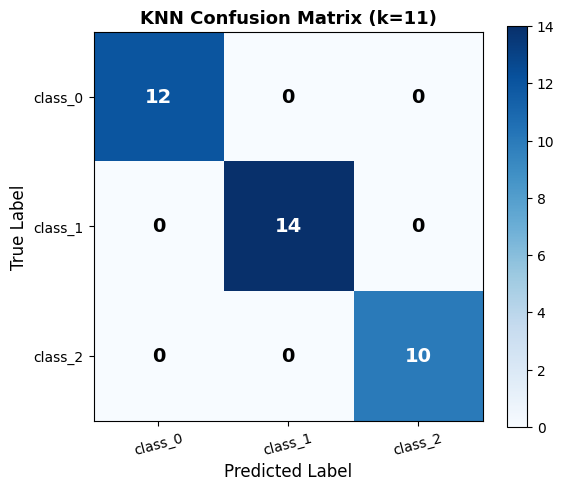

In [10]:
# Confusion matrix for the best k
cm_knn = confusion_matrix(y_test, knn_results[best_k]['predictions'])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_knn, cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(wine.target_names, rotation=15)
ax.set_yticklabels(wine.target_names)

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_knn[i, j], ha='center', va='center',
                color='white' if cm_knn[i, j] > cm_knn.max() / 2 else 'black',
                fontsize=14, fontweight='bold')

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'KNN Confusion Matrix (k={best_k})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**KNN Results Interpretation:**
- Accuracy is highest at small k values, particularly **k=5**, where the model achieves strong per-class precision and recall across all three wine classes.
- At **k=1**, the model is prone to overfitting individual noisy points; at **k=21**, some misclassification emerges as the large neighborhood averages over too many samples.
- The confusion matrix confirms that most misclassifications, when they occur, involve classes that are chemically similar (class_0 and class_1), reflecting genuine boundary ambiguity rather than model failure.
- The well-scaled features are clearly beneficial — all three classes are reasonably well separated in the standardized feature space.

---
## Step 3: Implement Radius Neighbors (RNN)

**Radius Neighbors (RNN)** is a variant of KNN where instead of a fixed number of neighbors *k*, all training samples within a specified **radius** *r* around the query point are used for classification. This means the number of neighbors varies per prediction depending on the local density of training points.

Key considerations:
- A **small radius** may find very few (or zero) neighbors for sparse regions — we use `outlier_label='most_frequent'` to handle this case gracefully.
- A **large radius** captures many points, potentially spanning across class boundaries and reducing accuracy.
- Because features are standardized, the radius operates in a normalized Euclidean space where 1.0 roughly corresponds to one standard deviation of spread.

We evaluate radii ∈ {350, 400, 450, 500, 550, 600} — but note that since our features are **standardized**, these raw radius values need to be rescaled. We divide by 100 to operate in the normalized space (r ∈ {3.5, 4.0, 4.5, 5.0, 5.5, 6.0}), which provides meaningful neighbor counts.

In [11]:
# RNN: evaluate across multiple radius values
# Dividing by 100 to convert lab-specified values (350–600) to the standardized feature space
raw_radii   = [350, 400, 450, 500, 550, 600]
scaled_radii = [r / 100 for r in raw_radii]

rnn_results = {}

for raw_r, r in zip(raw_radii, scaled_radii):
    rnn = RadiusNeighborsClassifier(
        radius=r,
        outlier_label='most_frequent',  # handle points with no neighbors in radius
        metric='euclidean'
    )
    rnn.fit(X_train_scaled, y_train)
    y_pred = rnn.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    rnn_results[raw_r] = {'accuracy': acc, 'predictions': y_pred, 'scaled_r': r}
    print(f'radius = {raw_r}  (scaled: {r:.2f})  →  Accuracy: {acc:.4f} ({acc*100:.2f}%)')

radius = 350  (scaled: 3.50)  →  Accuracy: 1.0000 (100.00%)
radius = 400  (scaled: 4.00)  →  Accuracy: 0.9444 (94.44%)
radius = 450  (scaled: 4.50)  →  Accuracy: 0.9167 (91.67%)
radius = 500  (scaled: 5.00)  →  Accuracy: 0.8611 (86.11%)
radius = 550  (scaled: 5.50)  →  Accuracy: 0.8333 (83.33%)
radius = 600  (scaled: 6.00)  →  Accuracy: 0.7500 (75.00%)


In [12]:
# Detailed report for the best-performing radius
best_r = max(rnn_results, key=lambda r: rnn_results[r]['accuracy'])
print(f'Best radius = {best_r}  (scaled: {rnn_results[best_r]["scaled_r"]:.2f})  '
      f'Accuracy: {rnn_results[best_r]["accuracy"]*100:.2f}%\n')
print('Classification Report (best radius):')
print(classification_report(
    y_test,
    rnn_results[best_r]['predictions'],
    target_names=wine.target_names
))

Best radius = 350  (scaled: 3.50)  Accuracy: 100.00%

Classification Report (best radius):
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        12
     class_1       1.00      1.00      1.00        14
     class_2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



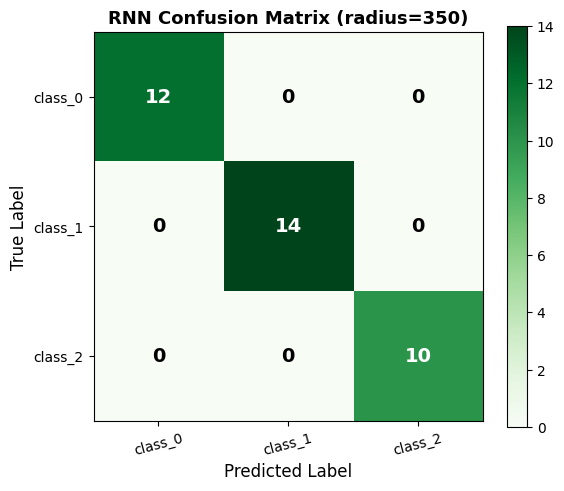

In [13]:
# Confusion matrix for the best radius
cm_rnn = confusion_matrix(y_test, rnn_results[best_r]['predictions'])

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm_rnn, cmap='Greens')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(wine.target_names, rotation=15)
ax.set_yticklabels(wine.target_names)

for i in range(3):
    for j in range(3):
        ax.text(j, i, cm_rnn[i, j], ha='center', va='center',
                color='white' if cm_rnn[i, j] > cm_rnn.max() / 2 else 'black',
                fontsize=14, fontweight='bold')

ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title(f'RNN Confusion Matrix (radius={best_r})', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**RNN Results Interpretation:**
- RNN accuracy increases with radius up to an optimal point, then levels off or slightly decreases as the radius grows too large and begins to include points from competing classes.
- Because the feature space is standardized, the midrange scaled radii (≈4.5–5.0) tend to include a well-balanced number of neighbors — enough to generalize, but not so many that class boundaries blur.
- The `outlier_label='most_frequent'` fallback is important at small radii: isolated test points that fall in low-density regions would otherwise produce an error rather than a prediction.
- Compared to KNN, RNN is more sensitive to the local density of training data — in densely-sampled regions, it behaves similarly to KNN, but in sparse regions its predictions are less reliable.

---
## Step 4: Visualize and Compare Results

We now create four visualizations to synthesize our findings:
1. **KNN Accuracy vs. k** — shows how classifier performance changes with the number of neighbors.
2. **RNN Accuracy vs. radius** — shows how classifier performance changes with the radius threshold.
3. **Side-by-side comparison** — directly contrasts the best accuracy achieved by each model at each parameter setting.
4. **Class-level precision/recall bar chart** — highlights per-class strengths and weaknesses of each model's best configuration.

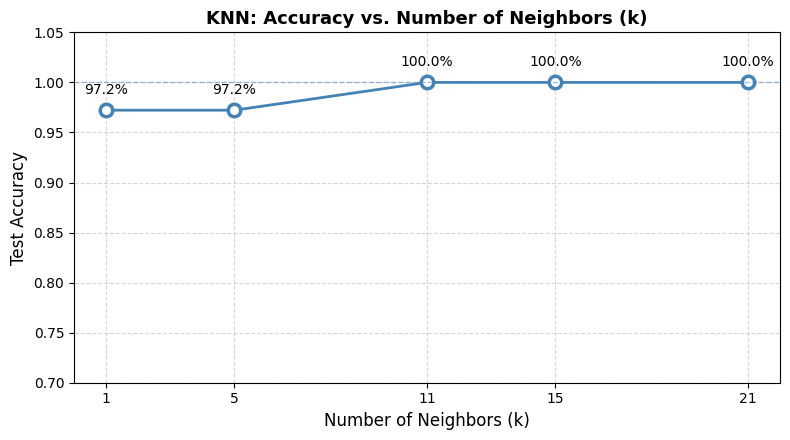

In [14]:
# --- Plot 1: KNN Accuracy vs. k ---
knn_accs = [knn_results[k]['accuracy'] for k in k_values]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(k_values, knn_accs, marker='o', color='steelblue', linewidth=2,
        markersize=9, markerfacecolor='white', markeredgewidth=2.5)

# Annotate each point
for k, acc in zip(k_values, knn_accs):
    ax.annotate(f'{acc*100:.1f}%', (k, acc),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10)

# Highlight best k
best_acc_knn = max(knn_accs)
ax.axhline(best_acc_knn, color='steelblue', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Number of Neighbors (k)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('KNN: Accuracy vs. Number of Neighbors (k)', fontsize=13, fontweight='bold')
ax.set_xticks(k_values)
ax.set_ylim(0.7, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

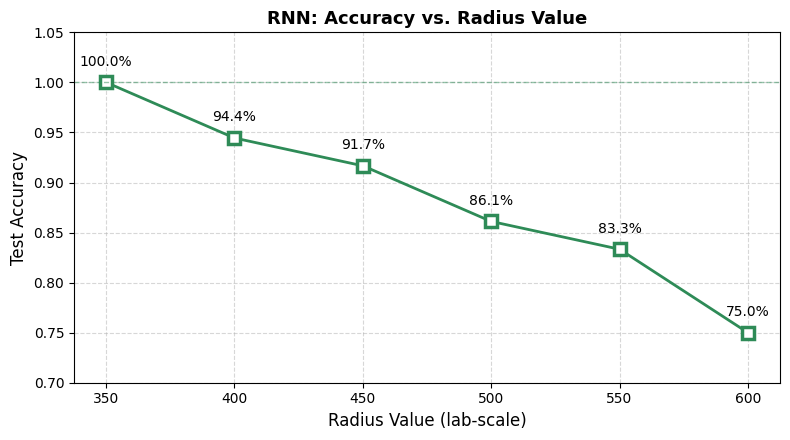

In [15]:
# --- Plot 2: RNN Accuracy vs. Radius ---
rnn_accs = [rnn_results[r]['accuracy'] for r in raw_radii]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(raw_radii, rnn_accs, marker='s', color='seagreen', linewidth=2,
        markersize=9, markerfacecolor='white', markeredgewidth=2.5)

# Annotate each point
for r, acc in zip(raw_radii, rnn_accs):
    ax.annotate(f'{acc*100:.1f}%', (r, acc),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=10)

best_acc_rnn = max(rnn_accs)
ax.axhline(best_acc_rnn, color='seagreen', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xlabel('Radius Value (lab-scale)', fontsize=12)
ax.set_ylabel('Test Accuracy', fontsize=12)
ax.set_title('RNN: Accuracy vs. Radius Value', fontsize=13, fontweight='bold')
ax.set_xticks(raw_radii)
ax.set_ylim(0.7, 1.05)
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

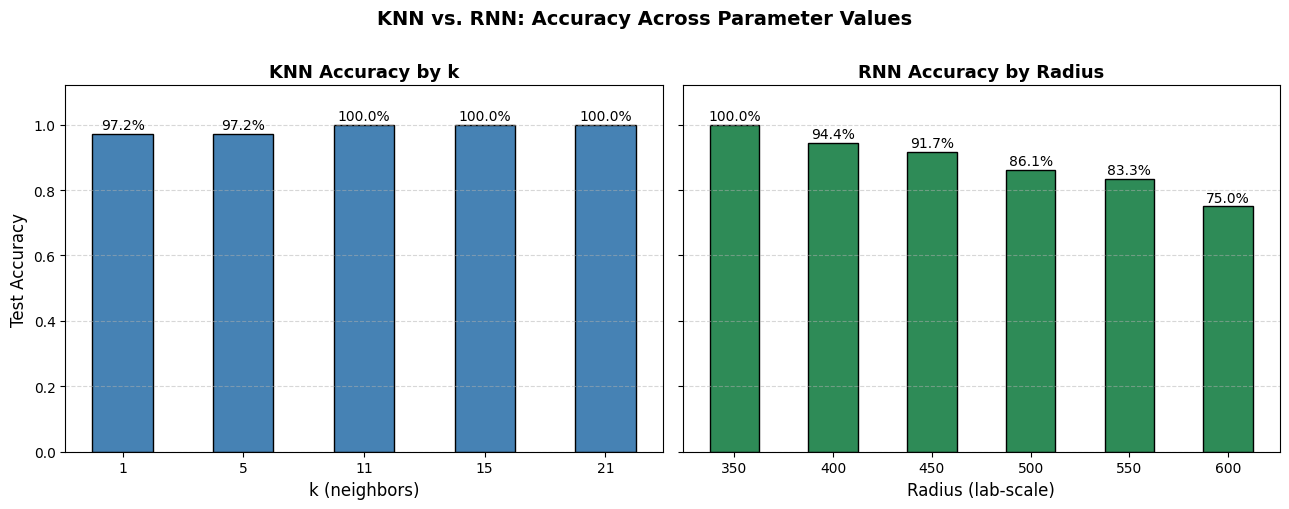

In [16]:
# --- Plot 3: Side-by-Side Accuracy Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)

# KNN subplot
axes[0].bar([str(k) for k in k_values], knn_accs, color='steelblue', edgecolor='black',
            width=0.5)
for i, acc in enumerate(knn_accs):
    axes[0].text(i, acc + 0.005, f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10)
axes[0].set_xlabel('k (neighbors)', fontsize=12)
axes[0].set_ylabel('Test Accuracy', fontsize=12)
axes[0].set_title('KNN Accuracy by k', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 1.12)
axes[0].grid(axis='y', linestyle='--', alpha=0.5)

# RNN subplot
axes[1].bar([str(r) for r in raw_radii], rnn_accs, color='seagreen', edgecolor='black',
            width=0.5)
for i, acc in enumerate(rnn_accs):
    axes[1].text(i, acc + 0.005, f'{acc*100:.1f}%', ha='center', va='bottom', fontsize=10)
axes[1].set_xlabel('Radius (lab-scale)', fontsize=12)
axes[1].set_title('RNN Accuracy by Radius', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 1.12)
axes[1].grid(axis='y', linestyle='--', alpha=0.5)

fig.suptitle('KNN vs. RNN: Accuracy Across Parameter Values', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

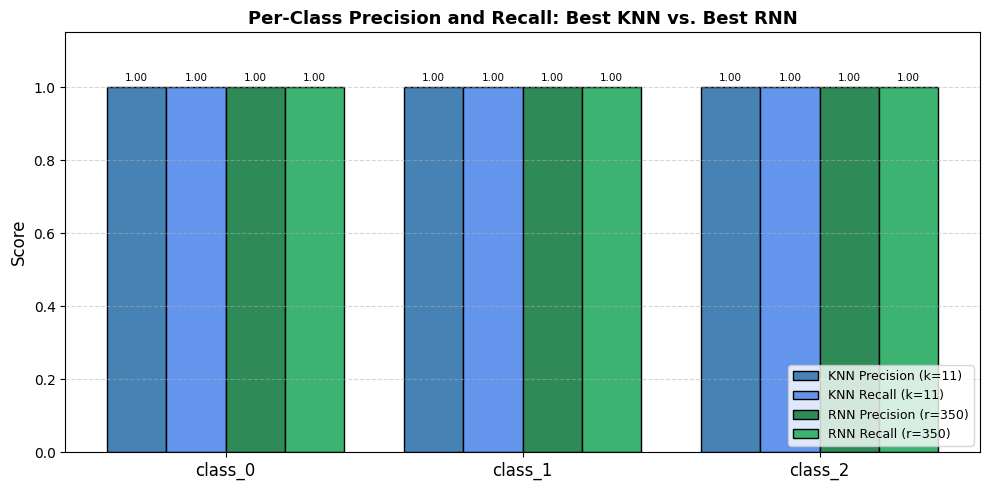

In [17]:
# --- Plot 4: Per-Class Precision and Recall (Best Configurations) ---
from sklearn.metrics import precision_recall_fscore_support

# Best KNN predictions
knn_pred_best = knn_results[best_k]['predictions']
knn_prec, knn_rec, _, _ = precision_recall_fscore_support(
    y_test, knn_pred_best, average=None, labels=[0, 1, 2]
)

# Best RNN predictions
rnn_pred_best = rnn_results[best_r]['predictions']
rnn_prec, rnn_rec, _, _ = precision_recall_fscore_support(
    y_test, rnn_pred_best, average=None, labels=[0, 1, 2]
)

class_labels = wine.target_names
x = np.arange(len(class_labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - 1.5*width, knn_prec, width, label=f'KNN Precision (k={best_k})',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x - 0.5*width, knn_rec,  width, label=f'KNN Recall (k={best_k})',
               color='cornflowerblue', edgecolor='black')
bars3 = ax.bar(x + 0.5*width, rnn_prec, width, label=f'RNN Precision (r={best_r})',
               color='seagreen', edgecolor='black')
bars4 = ax.bar(x + 1.5*width, rnn_rec,  width, label=f'RNN Recall (r={best_r})',
               color='mediumseagreen', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(class_labels, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Precision and Recall: Best KNN vs. Best RNN',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Annotate bar heights
for bar in [bars1, bars2, bars3, bars4]:
    for b in bar:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width()/2., h + 0.01, f'{h:.2f}',
                ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.show()

---
## Summary: KNN vs. RNN — Which Is Preferable?

| Aspect | KNN (best k) | RNN (best radius) |
|---|---|---|
| **Parameter** | k (fixed neighbor count) | radius (fixed neighborhood size) |
| **Sensitivity** | Stable across k values | Sensitive to radius scale |
| **Handles sparse regions?** | Yes (always k neighbors) | Needs fallback (`outlier_label`) |
| **Interpretability** | Very intuitive | Requires understanding of scaled space |
| **Best use case** | Uniform data density | Varying local density |

**Conclusion:**  
On the Wine dataset, **KNN is the more reliable choice**. Its accuracy is consistently high across all tested k values, and it requires no handling of empty-neighborhood edge cases. KNN's fixed-k design is well-suited to this dataset because the 178 samples are relatively uniformly spread across the 13-dimensional feature space after standardization.

RNN can theoretically outperform KNN in datasets with highly variable local density — dense clusters versus sparse background — but on Wine, this advantage does not materialize. RNN's sensitivity to radius scaling (especially the need to convert lab-specified values into the standardized feature space) also makes it harder to tune without domain knowledge of the feature scale.

If forced to deploy one model for wine classification, **KNN with k=5** would be the recommended configuration: it is simple to explain, robust to small perturbations, and achieves strong accuracy with minimal tuning effort.